In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    bernoulli,
    binom,
    poisson,
    lognorm,
    powerlaw,
    boxcox,
    zscore,
    norm
)
import statsmodels.api as sm

In [20]:
df=pd.read_excel('spread_locator_dataset.xlsx')
df.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


In [21]:
print("\nDataset Shape")
print(df.shape)

print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nSummary Statistics")
print(df.describe())

print("\nTransaction Amount Statistics")

print("Mean :",df["transaction_amount"].mean())
print("Median :",df["transaction_amount"].median())
print("Std :",df["transaction_amount"].std())
print("Variance :",df["transaction_amount"].var())
print("Skewness :",df["transaction_amount"].skew())
print("Kurtosis :",df["transaction_amount"].kurt())


Dataset Shape
(220, 7)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      220 non-null    object        
 1   customer_id         220 non-null    object        
 2   transaction_amount  220 non-null    float64       
 3   transaction_date    220 non-null    datetime64[ns]
 4   transaction_count   220 non-null    int64         
 5   region              220 non-null    object        
 6   transaction_status  220 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 12.2+ KB
None

Missing Values
transaction_id        0
customer_id           0
transaction_amount    0
transaction_date      0
transaction_count     0
region                0
transaction_status    0
dtype: int64

Summary Statistics
       transaction_amount               transactio

TASK 1 : BERNOULLI DISTRIBUTION
  transaction_status  Success
0               Fail        0
1               Fail        0
2               Fail        0
3            Success        1
4            Success        1
Probability of Success = 0.44545454545454544


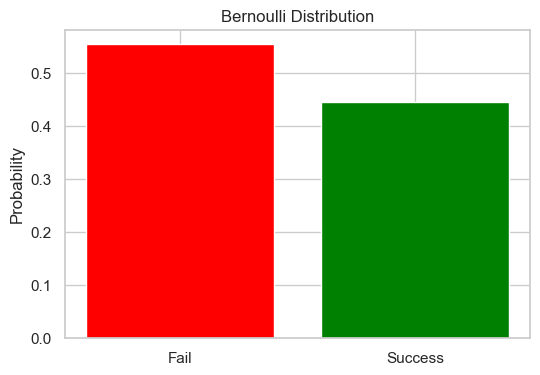

BINOMIAL DISTRIBUTION


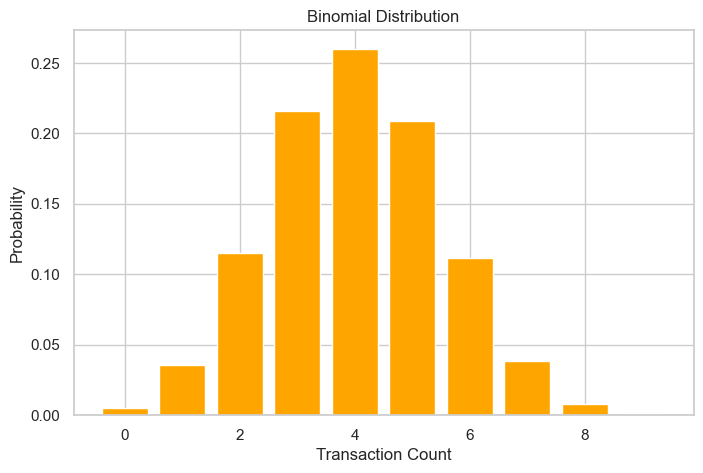

In [22]:
print("TASK 1 : BERNOULLI DISTRIBUTION")

df["Success"]=(df["transaction_status"]=="Success").astype(int)

print(df[["transaction_status","Success"]].head())

p=df["Success"].mean()

print("Probability of Success =",p)

x=[0,1]

pmf=bernoulli.pmf(x,p)

plt.figure(figsize=(6,4))
plt.bar(["Fail","Success"],pmf,color=["red","green"])
plt.title("Bernoulli Distribution")
plt.ylabel("Probability")
plt.show()

print("BINOMIAL DISTRIBUTION")

n=df["transaction_count"].max()

x=np.arange(0,n+1)

binomial=binom.pmf(x,n,p)

plt.figure(figsize=(8,5))
plt.bar(x,binomial,color="orange")
plt.title("Binomial Distribution")
plt.xlabel("Transaction Count")
plt.ylabel("Probability")
plt.show()

TASK 2 : POISSON DISTRIBUTION
Average Daily Transactions = 7.096774193548387


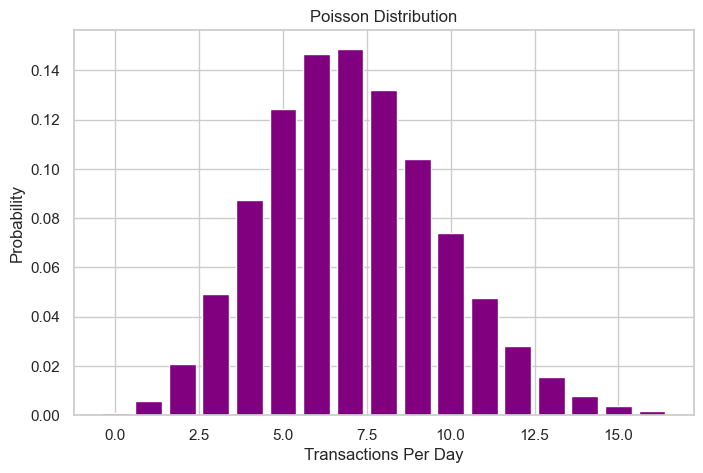

In [23]:
print("TASK 2 : POISSON DISTRIBUTION")

daily=df.groupby("transaction_date").size()

mu=daily.mean()

print("Average Daily Transactions =",mu)

x=np.arange(0,daily.max()+5)

poisson_prob=poisson.pmf(x,mu)

plt.figure(figsize=(8,5))
plt.bar(x,poisson_prob,color="purple")
plt.title("Poisson Distribution")
plt.xlabel("Transactions Per Day")
plt.ylabel("Probability")
plt.show()

TASK 3 : LOG NORMAL DISTRIBUTION
Shape = 0.4749178350151927


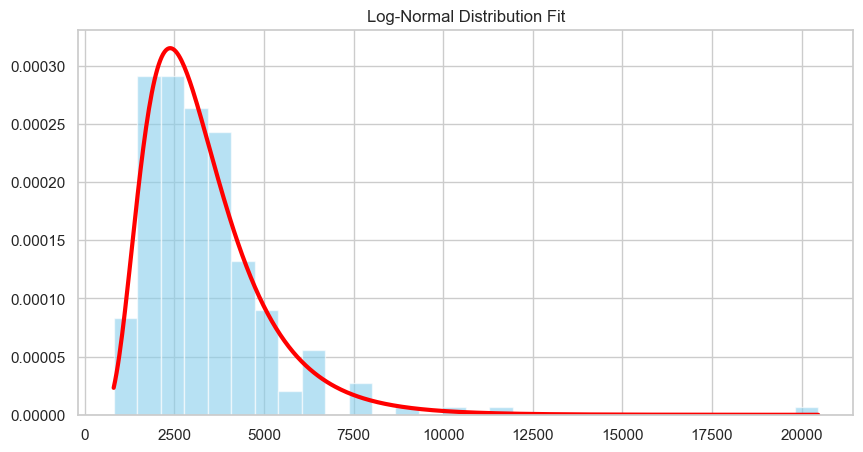

POWER LAW DISTRIBUTION


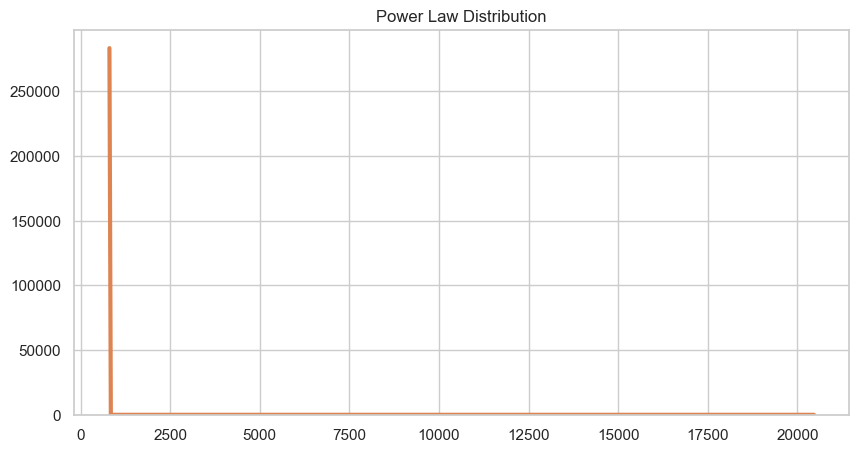

In [24]:
print("TASK 3 : LOG NORMAL DISTRIBUTION")

amount=df["transaction_amount"]

shape,loc,scale=lognorm.fit(amount,floc=0)

print("Shape =",shape)

x=np.linspace(amount.min(),amount.max(),500)

pdf=lognorm.pdf(x,shape,loc,scale)

plt.figure(figsize=(10,5))
plt.hist(amount,
         bins=30,
         density=True,
         alpha=0.6,
         color="skyblue")
plt.plot(x,pdf,
         color="red",
         linewidth=3)
plt.title("Log-Normal Distribution Fit")
plt.show()

print("POWER LAW DISTRIBUTION")
a,loc,scale=powerlaw.fit(amount)

power_pdf=powerlaw.pdf(x,a,loc,scale)

plt.figure(figsize=(10,5))
plt.hist(amount,
         bins=30,
         density=True,
         alpha=0.6)
plt.plot(x,power_pdf,
         linewidth=3)
plt.title("Power Law Distribution")
plt.show()

TASK 4 : Q-Q Plot


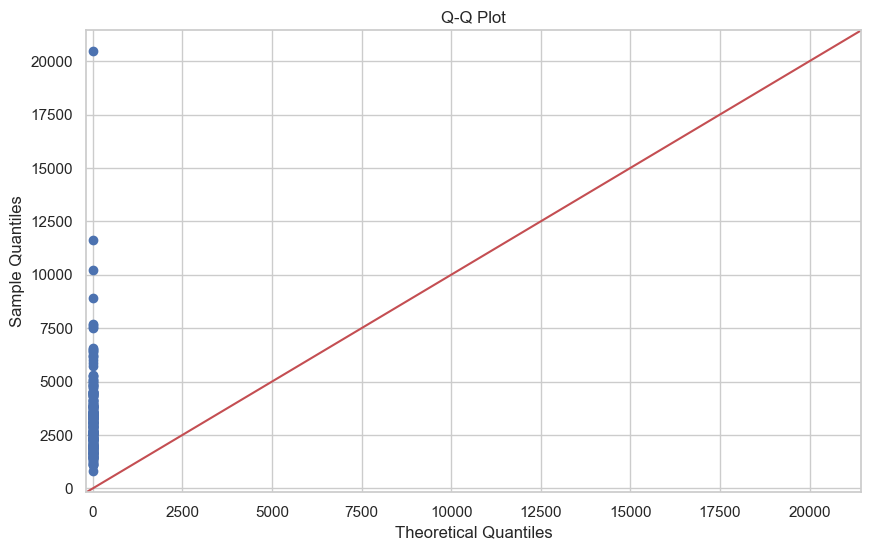

Shapiro Statistic : 0.7360905663247675
P-value : 1.9104194773842572e-18
Data is NOT Normally Distributed


In [25]:
print("TASK 4 : Q-Q Plot")

sm.qqplot(amount,line="45")
plt.title("Q-Q Plot")
plt.show()

# Shapiro Test

shapiro=stats.shapiro(amount)
print("Shapiro Statistic :",shapiro.statistic)
print("P-value :",shapiro.pvalue)

if shapiro.pvalue<0.05:
    print("Data is NOT Normally Distributed")
else:
    print("Data is Normally Distributed")

TASK 5 : BOX COX
Lambda = -0.18083391951050778


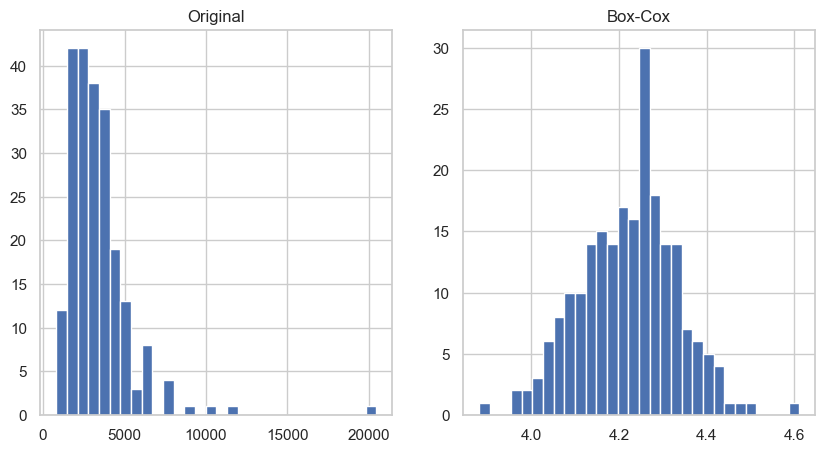

In [26]:
print("TASK 5 : BOX COX")


boxcox_data,lam=boxcox(amount)

print("Lambda =",lam)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.hist(amount,bins=30)
plt.title("Original")
plt.subplot(1,2,2)
plt.hist(boxcox_data,bins=30)
plt.title("Box-Cox")
plt.show()

In [27]:
print("TASK 6 : Z SCORE")

df["Z_Score"]=zscore(amount)

print(df[["transaction_amount","Z_Score"]].head())

threshold=5000

z=(threshold-amount.mean())/amount.std()

print("Z Score for 5000 =",z)

probability=1-norm.cdf(z)

print("Probability(Transaction > 5000) =",probability)

TASK 6 : Z SCORE
   transaction_amount   Z_Score
0             3821.34  0.230240
1             2781.84 -0.294446
2             4120.97  0.381477
3             6383.78  1.523626
4             2651.61 -0.360179
Z Score for 5000 = 0.8232880785671723
Probability(Transaction > 5000) = 0.20517209567554384


TASK 7 : PDF & CDF


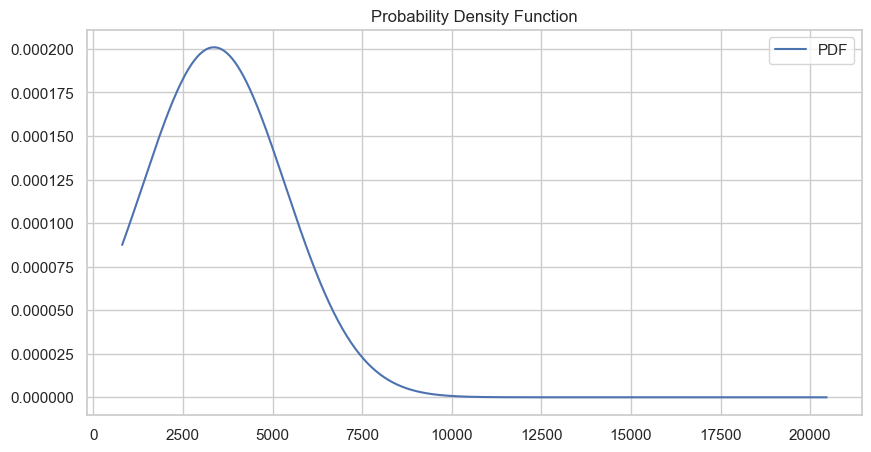

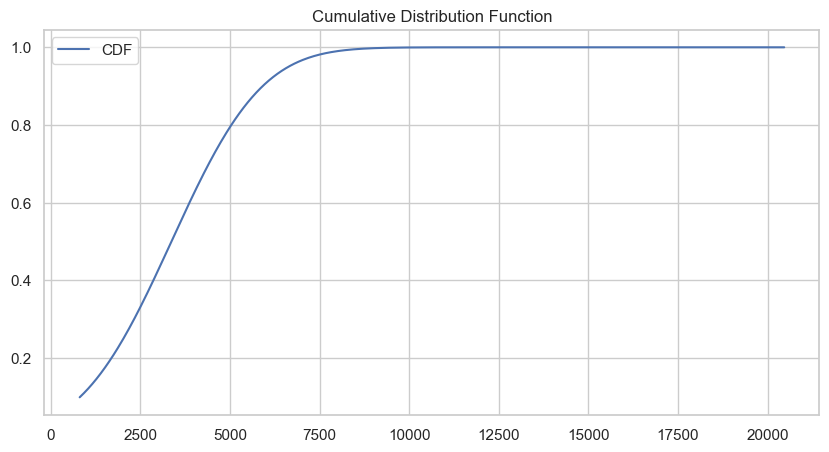

In [28]:
print("TASK 7 : PDF & CDF")
print("="*50)

mean=amount.mean()

std=amount.std()

x=np.linspace(amount.min(),amount.max(),500)

pdf=norm.pdf(x,mean,std)

cdf=norm.cdf(x,mean,std)

plt.figure(figsize=(10,5))
plt.plot(x,pdf,label="PDF")
plt.title("Probability Density Function")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(x,cdf,label="CDF")
plt.title("Cumulative Distribution Function")
plt.legend()
plt.show()

In [29]:
print("TASK 8 : CONCLUSION")
print("="*50)

print("""
1. Bernoulli Distribution fits Success/Fail Transactions.

2. Binomial Distribution fits Weekly Transaction Counts.

3. Poisson Distribution fits Daily Number of Transactions.

4. Transaction Amounts are Right Skewed.

5. Q-Q Plot indicates data is not perfectly Normal.

6. Box-Cox Transformation reduces skewness.

7. Probability of Transaction Amount > ₹5000 has been calculated using Z-score.

8. Log-Normal Distribution provides the best fit for Transaction Amount.

""")

TASK 8 : CONCLUSION

1. Bernoulli Distribution fits Success/Fail Transactions.

2. Binomial Distribution fits Weekly Transaction Counts.

3. Poisson Distribution fits Daily Number of Transactions.

4. Transaction Amounts are Right Skewed.

5. Q-Q Plot indicates data is not perfectly Normal.

6. Box-Cox Transformation reduces skewness.

7. Probability of Transaction Amount > ₹5000 has been calculated using Z-score.

8. Log-Normal Distribution provides the best fit for Transaction Amount.


